# 02c — Technical Indicators & Feature Selection (Weekly)

Weekly technical-indicator feature selection: operates on W-FRI aggregated weekly
data throughout — indicators are computed on weekly bars, feature selection is run
against weekly silver log-returns.

**Outputs**
- `selected_features_rf_weekly.csv` — RF importance selection for weekly RF / XGBoost / LSTM
- `selected_features_lasso_weekly.csv` — LASSO selection for weekly ARIMAX / VAR / MIDAS

Run after `02_features.ipynb`, before weekly model notebooks.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import warnings, os
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

RAW  = '../data/raw/'
PROC = '../data/processed/'

## 1. Aggregate to weekly and compute technical indicators

Silver price is aggregated to W-FRI (Friday close). All indicators are computed
on weekly bars so windows are in weeks: RSI-14 ≈ 3.5 months, Bollinger-20 ≈ 5 months.
Indicators are lagged by 1 week before use — no lookahead.

In [32]:
# Load daily prices and aggregate to weekly (Friday close)
prices = pd.read_csv(RAW + 'daily_prices.csv', index_col=0, parse_dates=True)
silver_w = prices['silver'].resample('W-FRI').last().dropna()

# ── RSI ──────────────────────────────────────────────────────────────────────
def rsi(s, window=14):
    delta    = s.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(span=window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(span=window, min_periods=window, adjust=False).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

# ── MACD ─────────────────────────────────────────────────────────────────────
def macd(s, fast=12, slow=26, signal=9):
    ema_fast    = s.ewm(span=fast,   adjust=False).mean()
    ema_slow    = s.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line, macd_line - signal_line

# ── Bollinger Bands ───────────────────────────────────────────────────────────
def bollinger(s, window=20, num_std=2):
    ma        = s.rolling(window).mean()
    std       = s.rolling(window).std()
    upper     = ma + num_std * std
    lower     = ma - num_std * std
    bandwidth = (upper - lower) / ma
    pct_b     = (s - lower) / (upper - lower)
    return bandwidth, pct_b

def price_ma_ratio(s, window):
    return s / s.rolling(window).mean() - 1

def roc(s, window):
    return s.pct_change(window)

# Build weekly indicator DataFrame
ind = pd.DataFrame(index=silver_w.index)

ind['rsi_14w']       = rsi(silver_w, 14)
ind['rsi_28w']       = rsi(silver_w, 28)

ml, sl, hist         = macd(silver_w, 12, 26, 9)
ind['macd_line']     = ml
ind['macd_signal']   = sl
ind['macd_hist']     = hist

bw, pb               = bollinger(silver_w, 20, 2)
ind['bb_bandwidth']  = bw
ind['bb_pct_b']      = pb

ind['price_ma5w']    = price_ma_ratio(silver_w, 5)
ind['price_ma13w']   = price_ma_ratio(silver_w, 13)   # quarter
ind['price_ma26w']   = price_ma_ratio(silver_w, 26)   # half year

ind['roc_4w']        = roc(silver_w, 4)    # ~monthly
ind['roc_13w']       = roc(silver_w, 13)   # ~quarterly

ind['silver_vol_5w'] = np.log(silver_w / silver_w.shift(1)).rolling(5).std()
ind['mom_5w']        = np.log(silver_w / silver_w.shift(1)).rolling(5).sum()

# Lag by 1 week — use last week's indicator to predict this week's return
ind = ind.shift(1)

print(f'Indicators computed: {ind.columns.tolist()}')
print(f'NaN rows at start:   {ind.isna().any(axis=1).sum()}')

Indicators computed: ['rsi_14w', 'rsi_28w', 'macd_line', 'macd_signal', 'macd_hist', 'bb_bandwidth', 'bb_pct_b', 'price_ma5w', 'price_ma13w', 'price_ma26w', 'roc_4w', 'roc_13w', 'silver_vol_5w', 'mom_5w']
NaN rows at start:   29


## 2. Build weekly feature matrix

Aggregate daily processed data to W-FRI, join technical indicators, align with
the same train split used by all weekly model notebooks.

In [ ]:
TARGET = 'silver_return'
EXOG   = ['gold_return', 'usd_return', 'copper_return', 'sp500_return',
          'vix_return', 'oil_return']

frames = []
for split in ['train', 'val', 'test']:
    df = pd.read_csv(PROC + f'{split}.csv', index_col=0, parse_dates=True)
    cols = [TARGET] + [c for c in EXOG if c in df.columns]
    agg  = {TARGET: 'sum', **{c: 'sum' for c in EXOG if c in df.columns}}
    weekly = df[cols].resample('W-FRI').agg(agg).dropna()
    # sentiment: mean over week, joined separately so NaN weeks don't drop return rows
    if 'sentiment_score' in df.columns:
        sent_w = df[['sentiment_score']].resample('W-FRI').mean()
        weekly = weekly.join(sent_w, how='left')
    frames.append(weekly)

train_w, val_w, test_w = frames
all_w   = pd.concat([train_w, val_w, test_w])
n_train = len(train_w) + len(val_w)

# Join technical indicators (already lagged by 1 week in Section 1)
all_w = all_w.join(ind.reindex(all_w.index), how='left')

# Lagged market returns
for col in EXOG:
    if col in all_w.columns:
        all_w[f'{col}_lag1'] = all_w[col].shift(1)

# Lag sentiment by 1 week — use last week's sentiment to predict this week's return
if 'sentiment_score' in all_w.columns:
    all_w['sentiment_score'] = all_w['sentiment_score'].shift(1)

# Silver autocorrelation lags
for lag in [1, 2, 3]:
    all_w[f'silver_lag{lag}'] = all_w[TARGET].shift(lag)

EXCLUDE  = {TARGET} | set(EXOG)   # raw (unlagged) market cols excluded from features
all_cols = [c for c in all_w.columns if c not in EXCLUDE]

train_block = all_w.iloc[:n_train]
X = train_block[all_cols].fillna(0).values
y = train_block[TARGET].fillna(0).values

print(f'Weekly obs — train+val: {n_train},  test: {len(test_w)}')
print(f'Feature cols ({len(all_cols)}): {all_cols}')

Weekly obs — train+val: 417,  test: 175
Feature cols (24): ['sentiment_score', 'rsi_14w', 'rsi_28w', 'macd_line', 'macd_signal', 'macd_hist', 'bb_bandwidth', 'bb_pct_b', 'price_ma5w', 'price_ma13w', 'price_ma26w', 'roc_4w', 'roc_13w', 'silver_vol_5w', 'mom_5w', 'gold_return_lag1', 'usd_return_lag1', 'copper_return_lag1', 'sp500_return_lag1', 'vix_return_lag1', 'oil_return_lag1', 'silver_lag1', 'silver_lag2', 'silver_lag3']


## 3. RF importance — for weekly RF / XGBoost / LSTM

Trains a Random Forest on the weekly training set and ranks features by MDI.
Results inform which features to add to `build_features()` in weekly model notebooks.

In [34]:
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)

imp       = pd.Series(rf.feature_importances_, index=all_cols).sort_values(ascending=False)
threshold = imp.mean()
selected  = imp[imp >= threshold].index.tolist()

print(f'Threshold (mean importance): {threshold:.5f}')
print(f'Selected: {len(selected)} / {len(all_cols)} features\n')
for f in selected:
    print(f'  {f:<30} {imp[f]:.5f}')

Threshold (mean importance): 0.04167
Selected: 9 / 24 features

  sentiment_score                0.11674
  oil_return_lag1                0.07317
  silver_lag3                    0.07069
  silver_lag2                    0.06890
  macd_hist                      0.06611
  usd_return_lag1                0.06123
  gold_return_lag1               0.05876
  macd_line                      0.05607
  bb_bandwidth                   0.04788


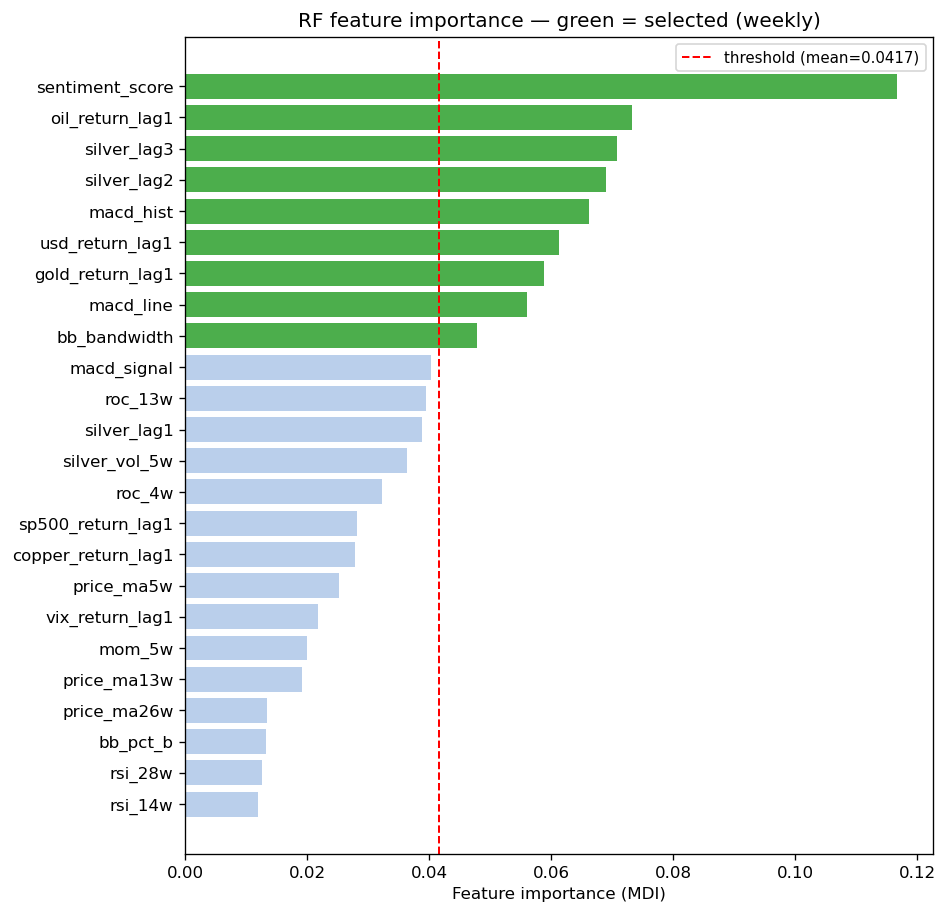

Saved selected_features_rf_weekly.csv


In [35]:
fig, ax = plt.subplots(figsize=(8, max(4, len(imp) * 0.28 + 1)))
colors = ['#2ca02c' if f in selected else '#aec7e8' for f in imp.index]
ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(threshold, color='red', lw=1.2, ls='--', label=f'threshold (mean={threshold:.4f})')
ax.set_xlabel('Feature importance (MDI)')
ax.set_title('RF feature importance — green = selected (weekly)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Save — suffix makes purpose explicit: RF importance, weekly frequency
out = pd.DataFrame({'feature': imp.index, 'importance': imp.values,
                    'selected': imp.index.isin(selected)})
out.to_csv(PROC + 'selected_features_rf_weekly.csv', index=False)
print('Saved selected_features_rf_weekly.csv')

## 4. LASSO selection — for weekly ARIMAX / VAR / MIDAS

LASSO with strict threshold (|coef| > 0.005) for linear models where multicollinearity
and too many regressors genuinely hurt.

In [ ]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
tscv     = TimeSeriesSplit(n_splits=5)
lasso    = LassoCV(cv=tscv, max_iter=10000, n_alphas=100, random_state=42)
lasso.fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_, index=all_cols)

# Threshold 0.0005 — weekly coefficients are small (few observations, noisy returns),
# so any non-zero survivor of LASSO is meaningful here.
THRESHOLD      = 0.0005
lasso_selected = lasso_coef[lasso_coef.abs() > THRESHOLD].sort_values(key=abs, ascending=False)

print(f'Alpha chosen by CV:  {lasso.alpha_:.6f}')
print(f'Raw non-zero:        {(lasso_coef != 0).sum()} / {len(all_cols)}')
print(f'Above threshold (|coef| > {THRESHOLD}): {len(lasso_selected)}\n')
print(lasso_selected.to_string())

lasso_nonzero = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, max(4, len(lasso_nonzero) * 0.32 + 1)))
colors = ['#2ca02c' if abs(v) > THRESHOLD else '#aec7e8' for v in lasso_nonzero.values]
ax.barh(lasso_nonzero.index[::-1], lasso_nonzero.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline( THRESHOLD, color='red', lw=1, ls='--', label=f'threshold ±{THRESHOLD}')
ax.axvline(-THRESHOLD, color='red', lw=1, ls='--')
ax.set_xlabel('LASSO coefficient (standardised)')
ax.set_title('LASSO coefficients — weekly — for ARIMAX / VAR / MIDAS')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Save — suffix makes purpose explicit: LASSO selection, weekly frequency
lasso_out = pd.DataFrame({
    'feature':  all_cols,
    'coef':     lasso_coef.values,
    'selected': lasso_coef.abs().values > THRESHOLD,
})
lasso_out.to_csv(PROC + 'selected_features_lasso_weekly.csv', index=False)
print(f'\nSaved selected_features_lasso_weekly.csv  ({len(lasso_selected)} features selected)')

## 5. How to use in weekly model notebooks

**Weekly RF / XGBoost / LSTM** — use RF importance selection:
```python
feat = pd.read_csv('../../data/processed/selected_features_rf_weekly.csv')
TECH_COLS = feat.loc[feat['selected'], 'feature'].tolist()
# add to build_features(): X[col] = df[col].shift(1) for col in TECH_COLS
```

**Weekly ARIMAX / VAR / MIDAS** — use LASSO selection:
```python
feat = pd.read_csv('../../data/processed/selected_features_lasso_weekly.csv')
TECH_COLS = feat.loc[feat['selected'], 'feature'].tolist()
```